# Part 7: Control Flow

**Goal**: Learn when and how to use JAX's structured control flow primitives — `lax.scan`, `lax.cond`, `lax.fori_loop`, and `lax.while_loop`. By the end, you'll build an autoregressive decoder with a KV-cache, the core pattern behind modern LLM inference.

---

## Table of Contents

1. **Why Python Control Flow Breaks Under JIT** — The tracing problem
2. **lax.cond and lax.switch** — Traced conditionals
3. **lax.fori_loop** — Fixed-count loops
4. **lax.scan — The Swiss Army Knife** — Carry state through a sequence
5. **lax.while_loop** — Data-dependent termination
6. **Decision Table** — When to use which
7. **Common Misconceptions** — What experienced engineers get wrong
8. **Capstone: Autoregressive Decoder with KV-Cache** — From attention to generation
9. **Summary — What To Do Next**

---

> **Prerequisites**: This notebook builds on **Notebooks 01–06**. We'll use pytree parameters and vmap. The cell below reconstructs the essentials.

In [2]:
# @title Setup { display-mode: "form" }

import jax
import jax.numpy as jnp
import jax.lax as lax
import numpy as np
import matplotlib.pyplot as plt
import time

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print(f"JAX version: {jax.__version__}")
print(f"Devices:     {jax.devices()}")

JAX version: 0.9.2
Devices:     [CpuDevice(id=0)]


In [3]:
# @title Reconstruct Utilities from Previous Notebooks { display-mode: "form" }

def init_dense(key, fan_in, fan_out):
    """Initialize a single dense layer as a pytree dict."""
    w_key, b_key = jax.random.split(key)
    return {
        'w': jax.random.normal(w_key, (fan_in, fan_out)) * jnp.sqrt(2.0 / fan_in),
        'b': jnp.zeros(fan_out),
    }

def dense_forward(params, x):
    """Dense layer forward pass."""
    return x @ params['w'] + params['b']

print("Dense layer utilities ready.")

Dense layer utilities ready.


---

# 1. Why Python Control Flow Breaks Under JIT

Recall from Notebook 02: [`jit`](https://jax.readthedocs.io/en/latest/_autosummary/jax.jit.html) **traces** your function by running it once with abstract placeholders. Python `for` and `if` are evaluated at trace time, not at execution time. This has two consequences:

1. **`for` loops unroll**: A Python `for` loop over 100 iterations runs 100 times *at trace time*, unrolling every iteration into the compiled graph. The compiled function has no loop — just 100 copies of the loop body. This is fine for short loops but explodes graph size for large ones.

2. **`if` statements branch on the first call only**: A Python `if x > 0:` evaluates the condition during tracing. The branch taken at trace time is the *only* branch that gets compiled. If `x` is negative on a later call, JAX will still run the positive branch — silently wrong results.

In [4]:
# This function uses a Python for-loop
def python_loop_sum(x, n=5):
    total = 0.0
    for i in range(n):
        total = total + x
    return total

# The loop unrolls during tracing — JAX sees 5 separate add operations
print("jaxpr for python_loop_sum(x, n=5):")
print(jax.make_jaxpr(python_loop_sum)(jnp.float32(1.0)))
print("\nThe loop became 5 separate adds. For n=5 this is fine.")
print("For n=10000, you'd get a jaxpr with 10,000 operations → slow compilation.")

jaxpr for python_loop_sum(x, n=5):
{ lambda ; a:f32[]. let
    b:f32[] = add 0.0:f32[] a
    c:f32[] = add b a
    d:f32[] = add c a
    e:f32[] = add d a
    f:f32[] = add e a
  in (f,) }

The loop became 5 separate adds. For n=5 this is fine.
For n=10000, you'd get a jaxpr with 10,000 operations → slow compilation.


In [5]:
def abs_value(x):
    if x >= 0:    # Python if on a traced value
        return x
    else:
        return -x

# Works outside jit (Python evaluates the if normally)
print(f"Without jit: abs_value(3.0) = {abs_value(3.0)}")
print(f"Without jit: abs_value(-3.0) = {abs_value(-3.0)}")

# Fails under jit (x is a tracer, not a concrete value)
try:
    jax.jit(abs_value)(jnp.float32(3.0))
except jax.errors.TracerBoolConversionError as e:
    print(f"\nWith jit: {type(e).__name__}: {e}")
    print(f"  The value of x is unknown at trace time — JAX can't choose a branch.")

Without jit: abs_value(3.0) = 3.0
Without jit: abs_value(-3.0) = 3.0

With jit: TracerBoolConversionError: Attempted boolean conversion of traced array with shape bool[].
The error occurred while tracing the function abs_value at /var/folders/xv/10y3vjpx44l9f9ctfbxcvd8c0000gn/T/ipykernel_21993/2511439246.py:3 for jit. This concrete value was not available in Python because it depends on the value of the argument x.
See https://docs.jax.dev/en/latest/errors.html#jax.errors.TracerBoolConversionError
  The value of x is unknown at trace time — JAX can't choose a branch.


The solution: JAX provides **structured control flow primitives** that work under tracing. They tell JAX "there's a conditional/loop here" so it can compile both branches or the loop body.

---

# 2. lax.cond and lax.switch — Traced Conditionals

`lax.cond(predicate, true_fn, false_fn, *operands)` is JAX's replacement for `if/else`. Both branches are compiled; only one executes at runtime.

> **`lax.cond` vs `jnp.where`**: `jnp.where(cond, a, b)` computes *both* `a` and `b` eagerly before selecting — the discarded branch still runs. `lax.cond` only executes the selected branch's callable at runtime. Use `lax.cond` when the branches are expensive functions or produce different shapes; use `jnp.where` for cheap element-wise selection between two pre-computed values.

In [ ]:
def safe_abs(x):
    return lax.cond(
        x >= 0,
        lambda x: x,        # True branch
        lambda x: -x,       # False branch
        x                   # Operand passed to whichever branch runs
    )

# Works under jit!
jit_abs = jax.jit(safe_abs)
print(f"safe_abs(3.0)  = {jit_abs(jnp.float32(3.0))}")
print(f"safe_abs(-3.0) = {jit_abs(jnp.float32(-3.0))}")

# And it's differentiable
print(f"grad(safe_abs)(3.0)  = {jax.grad(safe_abs)(3.0)}")
print(f"grad(safe_abs)(-3.0) = {jax.grad(safe_abs)(-3.0)}")

safe_abs(3.0)  = 3.0
safe_abs(-3.0) = 3.0
grad(safe_abs)(3.0)  = 1.0
grad(safe_abs)(-3.0) = -1.0


In [7]:
# lax.switch(index, [fn0, fn1, fn2, ...], *operands)
# Selects and runs the function at position `index`

def activation(x, mode):
    """Apply different activations based on mode (0=relu, 1=tanh, 2=identity)."""
    return lax.switch(
        mode,
        [
            lambda x: jnp.maximum(x, 0),     # mode 0: ReLU
            lambda x: jnp.tanh(x),            # mode 1: tanh
            lambda x: x,                      # mode 2: identity
        ],
        x
    )

jit_act = jax.jit(activation)
x = jnp.array([-1.0, 0.5, 2.0])
for mode in range(3):
    print(f"Mode {mode}: {jit_act(x, mode)}")

Mode 0: [0.  0.5 2. ]
Mode 1: [-0.7615942   0.46211717  0.9640276 ]
Mode 2: [-1.   0.5  2. ]


> **Important**: both branches of `lax.cond` are **compiled** but only one **executes**. This means both branches must be valid code — you can't have one branch that would error. But you don't pay the runtime cost of the branch that isn't taken.

---

# 3. lax.fori_loop — Fixed-Count Loops

`lax.fori_loop(lower, upper, body_fn, init_val)` runs `body_fn` a fixed number of times, threading state through each iteration. Use it when you need a fixed-count loop but don't need to collect intermediate results.

In [8]:
# Compute x + x + x + ... (n times) — equivalent to x * n
def repeated_add(x, n):
    return lax.fori_loop(
        0, n,
        lambda i, total: total + x,   # body_fn(i, carry) → new_carry
        0.0                             # initial carry
    )

jit_add = jax.jit(repeated_add, static_argnums=(1,))
print(f"1.0 added 5 times: {jit_add(1.0, 5)}")
print(f"3.0 added 10 times: {jit_add(3.0, 10)}")

# Timing: fori_loop vs Python loop under jit
def python_loop_add(x, n):
    total = 0.0
    for _ in range(n):
        total = total + x
    return total

# Compare jaxpr sizes
print(f"\nPython loop jaxpr (n=100): {len(str(jax.make_jaxpr(python_loop_add)(1.0, 100)))} chars")
print(f"fori_loop jaxpr (n=100):   {len(str(jax.make_jaxpr(repeated_add, static_argnums=(1,))(1.0, 100)))} chars")
print("\nfori_loop produces a compact jaxpr regardless of n.")

1.0 added 5 times: 5.0
3.0 added 10 times: 30.0


TracerIntegerConversionError: The __index__() method was called on traced array with shape int32[]
The error occurred while tracing the function python_loop_add at /var/folders/xv/10y3vjpx44l9f9ctfbxcvd8c0000gn/T/ipykernel_21993/1593967441.py:16 for jit. This concrete value was not available in Python because it depends on the value of the argument n.
See https://docs.jax.dev/en/latest/errors.html#jax.errors.TracerIntegerConversionError

---

# 4. lax.scan — The Swiss Army Knife

`scan` is the most important JAX control flow primitive.

**The three roles in a scan:**

| Variable | Role | Analogy |
|---|---|---|
| `carry` | State that persists step-to-step | A running total in a loop |
| `xs` | The sequence being consumed, one element per step | The list you're iterating over |
| `ys` (outputs) | Values collected from each step | Appending to a results list |

`carry` flows from one step into the next. `ys` accumulates into a stacked array. After all steps, you get `(final_carry, all_ys)`.
 It's like `fori_loop` but it also **collects outputs** at each step.

```python
def body_fn(carry, x):
    # carry: state that persists across iterations
    # x: one element from the input sequence
    new_carry = ...
    output = ...
    return new_carry, output

final_carry, all_outputs = lax.scan(body_fn, init_carry, xs)
```

Think of it as `functools.reduce` that also records the intermediate results.

> **Return value**: `lax.scan` returns `(final_carry, stacked_outputs)`. `final_carry` is the state *after* the last step. `stacked_outputs` is every per-step `output` stacked into a single array — equivalent to `jnp.stack([step_output_0, step_output_1, ...])`.

> **The mental model**: scan processes a sequence one element at a time, maintaining state in the carry and collecting one output per step.

In [ ]:
# Cumulative sum: carry is the running total, output is the total at each step
def cumsum_step(carry, x):
    new_total = carry + x
    return new_total, new_total  # (new_carry, output)

xs = jnp.array([1.0, 2.0, 3.0, 4.0, 5.0])
final_total, running_totals = lax.scan(cumsum_step, 0.0, xs)

print(f"Input:          {xs}")
print(f"Running totals: {running_totals}")
print(f"Final total:    {final_total}")
print(f"\njnp.cumsum:     {jnp.cumsum(xs)}")
print("Same result — but scan generalizes to ANY sequential computation.")

Input:          [1. 2. 3. 4. 5.]
Running totals: [ 1.  3.  6. 10. 15.]
Final total:    15.0



jnp.cumsum:     [ 1.  3.  6. 10. 15.]
Same result — but scan generalizes to ANY sequential computation.


In [ ]:
# A common pattern: thread a PRNG key through scan
# At each step, split the key, use one subkey, carry the other forward

def noisy_step(carry, x):
    key, running_sum = carry
    key, subkey = jax.random.split(key)
    noise = jax.random.normal(subkey) * 0.1
    new_sum = running_sum + x + noise
    return (key, new_sum), new_sum

key = jax.random.PRNGKey(0)
xs = jnp.ones(10)

(final_key, final_sum), trajectory = lax.scan(noisy_step, (key, 0.0), xs)

print(f"Noisy cumulative sum (10 steps, noise_scale=0.1):")
print(f"  Trajectory: {trajectory}")
print(f"  Final sum: {final_sum:.4f} (deterministic sum would be 10.0)")
print(f"\nThe PRNG key was properly split at each step — no key reuse.")

Noisy cumulative sum (10 steps, noise_scale=0.1):
  Trajectory: [0.7557544 1.6300067 2.49123   3.2610033 4.1595254 5.1397076 6.109488
 7.035211  8.015173  8.983397 ]
  Final sum: 8.9834 (deterministic sum would be 10.0)

The PRNG key was properly split at each step — no key reuse.


In [ ]:
# Process input through N identical layers using scan
# This is more efficient than a Python for-loop over layers

def init_stacked_layers(key, n_layers, dim):
    """Initialize N identical layers."""
    keys = jax.random.split(key, n_layers)
    # Stack parameters: each array has a leading 'layer' dimension
    return {
        'w': jax.vmap(lambda k: jax.random.normal(k, (dim, dim)) * jnp.sqrt(2.0 / dim))(keys),
        'b': jnp.zeros((n_layers, dim)),
    }

def scan_layers(stacked_params, x):
    """Process x through stacked layers using scan."""
    def layer_step(x, layer_params):
        # x is carry, layer_params is one slice of the stacked arrays
        x = x @ layer_params['w'] + layer_params['b']
        x = jnp.maximum(x, 0)
        return x, None  # carry forward, no per-step output needed

    final_x, _ = lax.scan(layer_step, x, stacked_params)
    return final_x

key = jax.random.PRNGKey(0)
stacked = init_stacked_layers(key, n_layers=8, dim=32)
x = jax.random.normal(jax.random.PRNGKey(1), (32,))

out = jax.jit(scan_layers)(stacked, x)
print(f"Input shape:  {x.shape}")
print(f"Output shape: {out.shape}")
print(f"Stacked weight shape: {stacked['w'].shape}  (n_layers × dim × dim)")
print(f"\nscan slices along axis 0 of each array in the pytree.")
print(f"Each step gets one layer's params — no Python loop needed.")

Input shape:  (32,)
Output shape: (32,)
Stacked weight shape: (8, 32, 32)  (n_layers × dim × dim)

scan slices along axis 0 of each array in the pytree.
Each step gets one layer's params — no Python loop needed.


---

# 5. lax.while_loop — Data-Dependent Termination

`lax.while_loop(cond_fn, body_fn, init_val)` runs until `cond_fn` returns False. Use it when the number of iterations depends on the data (e.g., iterative solvers).

> **Key difference from `scan`**: Because `while_loop` doesn't know how many iterations it will run at compile time, it cannot collect outputs into a fixed-size array. The only output is the final carry — the state after the loop terminates. If you need intermediate outputs, you must write them into a pre-allocated buffer inside the carry.

In [ ]:
def newton_sqrt(a, tol=1e-6):
    """Compute sqrt(a) using Newton's method: x_{n+1} = (x + a/x) / 2."""

    def cond_fn(state):
        x, prev_x, _ = state
        return jnp.abs(x - prev_x) > tol

    def body_fn(state):
        x, _, n_iters = state
        new_x = (x + a / x) / 2.0
        return (new_x, x, n_iters + 1)

    # Initial guess: a/2
    init_state = (a / 2.0, 0.0, 0)
    final_x, _, n_iters = lax.while_loop(cond_fn, body_fn, init_state)
    return final_x, n_iters

# Test
jit_sqrt = jax.jit(newton_sqrt)
for val in [2.0, 9.0, 100.0, 12345.0]:
    result, iters = jit_sqrt(val)
    exact = jnp.sqrt(val)
    print(f"sqrt({val:>8.1f}) = {result:.8f}  (exact: {exact:.8f}, iters: {iters})")

print("\nwhile_loop terminates when convergence is reached — iteration count varies.")

sqrt(     2.0) = 1.41421354  (exact: 1.41421354, iters: 5)
sqrt(     9.0) = 3.00000000  (exact: 3.00000000, iters: 5)
sqrt(   100.0) = 10.00000000  (exact: 10.00000000, iters: 7)
sqrt( 12345.0) = 111.10805511  (exact: 111.10805511, iters: 11)

while_loop terminates when convergence is reached — iteration count varies.


---

# 6. Decision Table — When to Use Which

| Scenario | Use | Why |
|---|---|---|
| Fixed iterations, need intermediates | **`lax.scan`** | Collects outputs, efficient under JIT |
| Fixed iterations, only final result | **`lax.fori_loop`** | Slightly simpler API than scan |
| Small fixed loop (< ~10 iters) | **Python `for`** | Unrolling is fine for small loops |
| Data-dependent termination | **`lax.while_loop`** | Only option for "run until converged" |
| Conditional (if/else) | **`lax.cond`** | Traced conditional, both branches compiled |
| Multi-way conditional | **`lax.switch`** | Selects one of N branches by index |
| Simple element-wise conditional | **[`jnp.where`](https://jax.readthedocs.io/en/latest/_autosummary/jax.numpy.where.html)** | No branch overhead, evaluates both sides |

The most common by far is **scan** — it handles training loops, RNNs, sequential models, autoregressive generation, and any "process a sequence while maintaining state" pattern.

---

# 7. Common Misconceptions

## Misconception: "scan is slow because it's sequential"

scan compiles to a single XLA while-loop. XLA can optimize the loop body aggressively — fusing operations, reusing buffers, and sometimes even unrolling short loops. The overhead of scan vs. an unrolled Python loop is typically zero after compilation. The sequential *semantics* don't prevent hardware-level optimizations within each step.

## Misconception: "I should always use lax loops instead of Python loops"

No. Short Python loops (under ~10 iterations) that iterate over **static** structures (like layers in a model) are perfectly fine. They unroll at trace time, which means XLA sees all operations and can optimize across loop iterations. The unrolled jaxpr is slightly larger, but compilation handles it fine.

Use `lax.scan` when the number of iterations is **large** (hundreds to millions) or when you want to avoid recompilation if the count changes.

## Misconception: "Both branches of lax.cond execute at runtime"

Both branches are **compiled** (so both must be valid code), but only one **executes**. The runtime cost is the cost of the taken branch, not both branches. The compilation cost includes both branches, but that happens once.

## Misconception: "KV-cache is only for transformer models"

The KV-cache pattern — maintaining a growing context to avoid recomputation during autoregressive generation — applies to any model that attends to its own history. RNNs naturally do this (their hidden state is the "cache"), but explicitly caching key/value projections is useful whenever attention is involved, whether in transformers, state-space models with attention, or hybrid architectures.

---

# 8. Capstone: Autoregressive Decoder with KV-Cache

Let's build something real: a small autoregressive decoder that generates sequences token-by-token using scan and a KV-cache. This is the core inference pattern behind every modern LLM.

## The Architecture

We'll build a simplified transformer decoder with:
- Token embeddings
- Causal self-attention with KV-cache
- A feedforward layer
- Multiple layers stacked with scan

## Why the KV-Cache?

During autoregressive generation, each new token attends to all previous tokens. Without caching, you'd recompute the key and value projections for the entire history at every step. Why O(n²)? At step `t`, you recompute projections for all `t` prior tokens — O(t) work. Summed over all `n` steps: O(1) + O(2) + … + O(n) = O(n²) total. The KV-cache stores these projections, so each new step only computes the projection for the **new** token — O(1) per step, O(n) total.

In [ ]:
# @title Decoder Configuration and Initialization { display-mode: "form" }

# Hyperparameters
VOCAB_SIZE = 64
D_MODEL = 64
N_HEADS = 4
D_HEAD = D_MODEL // N_HEADS  # 16
D_FF = 128
N_LAYERS = 2
MAX_SEQ_LEN = 128

def init_attention_params(key, d_model, n_heads, d_head):
    """Initialize multi-head attention parameters."""
    keys = jax.random.split(key, 4)
    scale = jnp.sqrt(2.0 / d_model)
    return {
        'wq': jax.random.normal(keys[0], (d_model, n_heads, d_head)) * scale,
        'wk': jax.random.normal(keys[1], (d_model, n_heads, d_head)) * scale,
        'wv': jax.random.normal(keys[2], (d_model, n_heads, d_head)) * scale,
        'wo': jax.random.normal(keys[3], (n_heads, d_head, d_model)) * scale,
    }

def init_ff_params(key, d_model, d_ff):
    """Initialize feedforward layer parameters."""
    k1, k2 = jax.random.split(key)
    return {
        'w1': jax.random.normal(k1, (d_model, d_ff)) * jnp.sqrt(2.0 / d_model),
        'b1': jnp.zeros(d_ff),
        'w2': jax.random.normal(k2, (d_ff, d_model)) * jnp.sqrt(2.0 / d_ff),
        'b2': jnp.zeros(d_model),
    }

def init_decoder_params(key):
    """Initialize all decoder parameters."""
    keys = jax.random.split(key, 2 + 2 * N_LAYERS)

    params = {
        'embedding': jax.random.normal(keys[0], (VOCAB_SIZE, D_MODEL)) * 0.02,
        'unembed': jax.random.normal(keys[1], (D_MODEL, VOCAB_SIZE)) * 0.02,
        'layers': [],
    }

    for i in range(N_LAYERS):
        attn_key = keys[2 + 2 * i]
        ff_key = keys[2 + 2 * i + 1]
        params['layers'].append({
            'attn': init_attention_params(attn_key, D_MODEL, N_HEADS, D_HEAD),
            'ff': init_ff_params(ff_key, D_MODEL, D_FF),
        })

    return params

key = jax.random.PRNGKey(42)
params = init_decoder_params(key)

n_params = sum(x.size for x in jax.tree.leaves(params))
print(f"Decoder: {N_LAYERS} layers, {N_HEADS} heads, d_model={D_MODEL}")
print(f"Total parameters: {n_params:,}")

Decoder: 2 layers, 4 heads, d_model=64
Total parameters: 74,112


## A Quick Note on [`jnp.einsum`](https://jax.readthedocs.io/en/latest/_autosummary/jax.numpy.einsum.html)
To calculate multi-head attention, we project vectors into matrices using Einstein summation (`einsum`). If you haven't seen it before, [`jnp.einsum('d,dhk->hk', x, wq)`](https://jax.readthedocs.io/en/latest/_autosummary/jax.numpy.einsum.html) simply means:
1. Take input `x` of dimension `d`
2. Multiply it by weight `wq` of dimensions `d` × `h` × `k`
3. Sum out the common `d` dimension, outputting a cleanly projected tensor of shape `h` × `k`.

In [ ]:
def attention_with_cache(attn_params, x, cache_k, cache_v, step):
    """Causal self-attention with KV-cache.

    During generation:
      - x is a single token embedding: shape (d_model,)
      - cache_k, cache_v hold the projected keys/values for all previous tokens
      - step is the current position in the sequence

    Returns:
      - output: (d_model,) — the attention output for this token
      - new_cache_k, new_cache_v: updated caches
    """
    # Project query, key, value for the new token
    q = jnp.einsum('d,dhk->hk', x, attn_params['wq'])   # (n_heads, d_head)
    k = jnp.einsum('d,dhk->hk', x, attn_params['wk'])   # (n_heads, d_head)
    v = jnp.einsum('d,dhk->hk', x, attn_params['wv'])   # (n_heads, d_head)

    # Update cache: store new k, v at position `step`
    new_cache_k = cache_k.at[step].set(k)  # (max_seq_len, n_heads, d_head)
    new_cache_v = cache_v.at[step].set(v)

    # Attention: query attends to all cached keys up to current step
    # scores: (n_heads, max_seq_len) — dot product of q with each cached k
    scores = jnp.einsum('hk,shk->hs', q, new_cache_k) / jnp.sqrt(D_HEAD)

    # Causal mask: only attend to positions <= step
    mask = jnp.arange(MAX_SEQ_LEN) <= step
    scores = jnp.where(mask[None, :], scores, -1e9)

    weights = jax.nn.softmax(scores, axis=-1)  # (n_heads, max_seq_len)

    # Weighted sum of cached values
    attn_out = jnp.einsum('hs,shk->hk', weights, new_cache_v)  # (n_heads, d_head)

    # Project back to d_model
    output = jnp.einsum('hk,hkd->d', attn_out, attn_params['wo'])  # (d_model,)

    return output, new_cache_k, new_cache_v

print("Attention with KV-cache defined.")
print(f"Cache shape per layer: ({MAX_SEQ_LEN}, {N_HEADS}, {D_HEAD})")

Attention with KV-cache defined.
Cache shape per layer: (128, 4, 16)


In [ ]:
def feedforward(ff_params, x):
    """Simple feedforward: Linear → ReLU → Linear."""
    h = jnp.maximum(x @ ff_params['w1'] + ff_params['b1'], 0)
    return h @ ff_params['w2'] + ff_params['b2']

print("Feedforward layer defined.")

Feedforward layer defined.


In [ ]:
def decoder_step(params, token_id, cache, step):
    """Process one token through the full decoder.

    Args:
        params: all decoder parameters
        token_id: integer token ID
        cache: list of (cache_k, cache_v) per layer
        step: current sequence position

    Returns:
        logits: (vocab_size,) — unnormalized scores for next token
        new_cache: updated KV-cache
    """
    # Embed the token
    x = params['embedding'][token_id]  # (d_model,)

    # Process through each layer
    new_cache = []
    for i, layer_params in enumerate(params['layers']):
        cache_k, cache_v = cache[i]

        # Self-attention with cache
        attn_out, new_ck, new_cv = attention_with_cache(
            layer_params['attn'], x, cache_k, cache_v, step
        )
        x = x + attn_out  # Residual connection

        # Feedforward
        ff_out = feedforward(layer_params['ff'], x)
        x = x + ff_out    # Residual connection

        new_cache.append((new_ck, new_cv))

    # Project to vocabulary
    logits = x @ params['unembed']  # (vocab_size,)
    return logits, new_cache

# Initialize empty cache
def make_empty_cache():
    return [
        (jnp.zeros((MAX_SEQ_LEN, N_HEADS, D_HEAD)),   # cache_k
         jnp.zeros((MAX_SEQ_LEN, N_HEADS, D_HEAD)))    # cache_v
        for _ in range(N_LAYERS)
    ]

# Test: one forward step
cache = make_empty_cache()
logits, new_cache = decoder_step(params, 0, cache, 0)
print(f"Logits shape: {logits.shape}")
print(f"Cache updated: {new_cache[0][0][0, 0, :4]}... (no longer all zeros)")

Logits shape: (64,)
Cache updated: [-0.02814262 -0.01976526  0.0678882  -0.01440625]... (no longer all zeros)


In [ ]:
def generate(params, prompt_tokens, max_new_tokens, temperature=1.0):
    """Generate tokens autoregressively using scan.

    Args:
        params: decoder parameters
        prompt_tokens: array of token IDs for the prompt
        max_new_tokens: how many tokens to generate
        temperature: sampling temperature (higher = more random)

    Returns:
        generated_tokens: array of generated token IDs
    """
    # --- Phase 1: Prefill (process the prompt) ---
    cache = make_empty_cache()
    for i in range(len(prompt_tokens)):
        logits, cache = decoder_step(params, prompt_tokens[i], cache, i)

    # The last logits from prefill predict the first new token
    prompt_len = len(prompt_tokens)

    # --- Phase 2: Decode (generate new tokens using scan) ---
    def decode_step(carry, _):
        """One autoregressive decode step.

        carry: (cache, prev_logits, key, step)
        input: ignored (we use a dummy sequence to control length)
        output: generated token ID
        """
        cache, prev_logits, key, step = carry

        # Sample next token from logits
        key, subkey = jax.random.split(key)
        token = jax.random.categorical(subkey, prev_logits / temperature)

        # Feed token through decoder, update cache
        new_logits, new_cache = decoder_step(params, token, cache, step)

        return (new_cache, new_logits, key, step + 1), token

    key = jax.random.PRNGKey(0)
    init_carry = (cache, logits, key, prompt_len)
    dummy_xs = jnp.zeros(max_new_tokens)  # lax.scan loops strictly based on the length of this input array, so we pass a dummy of zeros!

    _, generated_tokens = lax.scan(decode_step, init_carry, dummy_xs)

    return generated_tokens

# Generate!
prompt = jnp.array([1, 5, 10, 20])  # Arbitrary prompt tokens
generated = generate(params, prompt, max_new_tokens=20)
print(f"Prompt tokens:    {prompt}")
print(f"Generated tokens: {generated}")
print(f"\nThe tokens are meaningless (random weights), but the MECHANISM is correct:")
print(f"  • KV-cache avoids recomputing attention over the full history")
print(f"  • scan handles the autoregressive loop efficiently")
print(f"  • PRNG keys are properly threaded through scan's carry")


Prompt tokens:    [ 1  5 10 20]
Generated tokens: [ 9 61 59 33 31 46 18 18 61 37 61 43 50  6 43  1 14 32 48 22]

The tokens are meaningless (random weights), but the MECHANISM is correct:
  • KV-cache avoids recomputing attention over the full history
  • scan handles the autoregressive loop efficiently
  • PRNG keys are properly threaded through scan's carry


In [ ]:
# @title JIT-Compile and Benchmark { display-mode: "form" }

# JIT the generate function (static_argnums for prompt length and max_new_tokens)
@jax.jit
def generate_jit(params, prompt_tokens, key, temperature=1.0):
    """JIT-friendly version with fixed shapes."""
    max_new_tokens = 50

    # Prefill
    cache = make_empty_cache()
    def prefill_step(carry, token):
        cache, step = carry
        _, new_cache = decoder_step(params, token, cache, step)
        return (new_cache, step + 1), None

    (cache, prompt_len), _ = lax.scan(prefill_step, (cache, 0), prompt_tokens)

    # Get logits for first new token
    logits, cache = decoder_step(params, prompt_tokens[-1], cache, prompt_len - 1)

    # Decode
    def decode_step(carry, _):
        cache, prev_logits, key, step = carry
        key, subkey = jax.random.split(key)
        token = jax.random.categorical(subkey, prev_logits / temperature)
        new_logits, new_cache = decoder_step(params, token, cache, step)
        return (new_cache, new_logits, key, step + 1), token

    init_carry = (cache, logits, key, prompt_len)
    _, tokens = lax.scan(decode_step, init_carry, jnp.zeros(max_new_tokens))
    return tokens

# Warm up (first call includes compilation)
prompt = jnp.array([1, 5, 10, 20])
key = jax.random.PRNGKey(0)

print("Compiling (first call)...")
start = time.time()
tokens = generate_jit(params, prompt, key)
tokens.block_until_ready()
compile_time = time.time() - start
print(f"  Compilation + execution: {compile_time:.2f}s")

# Benchmark (subsequent calls — no recompilation)
n_runs = 20
start = time.time()
for i in range(n_runs):
    tokens = generate_jit(params, prompt, jax.random.PRNGKey(i))
    tokens.block_until_ready()
avg_time = (time.time() - start) / n_runs

print(f"\n  Average generation time (50 tokens): {avg_time*1000:.1f} ms")
print(f"  Tokens/second: {50/avg_time:.0f}")
print(f"\nThis is a toy model — real LLMs are larger but use the SAME pattern.")

Compiling (first call)...


  Compilation + execution: 0.15s

  Average generation time (50 tokens): 1.0 ms
  Tokens/second: 50020

This is a toy model — real LLMs are larger but use the SAME pattern.


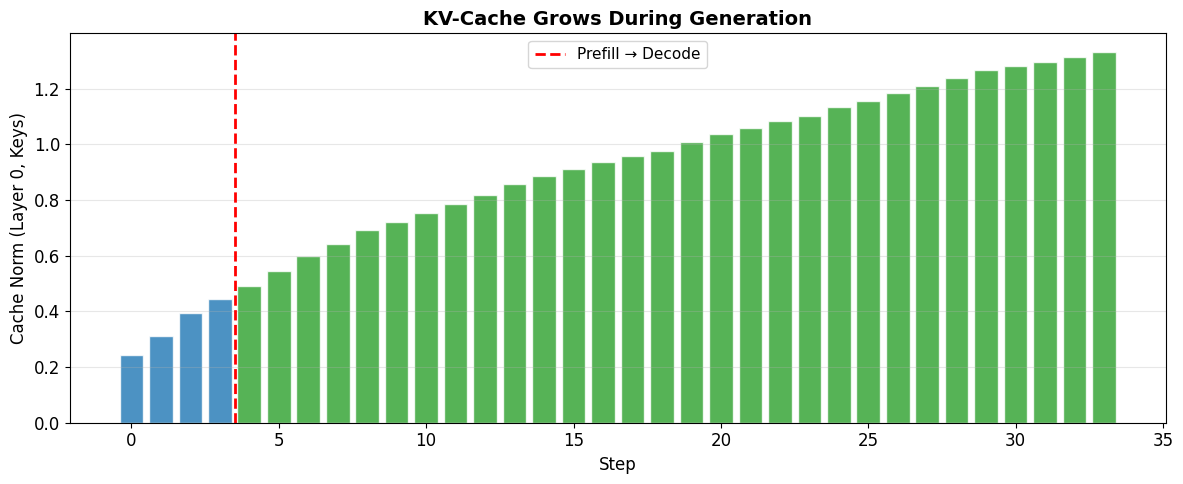

Blue = prefill (process prompt), Green = decode (generate new tokens)
The cache grows linearly — each new token adds one entry.
Without the cache, we'd recompute ALL entries at every step.


In [ ]:
# @title Visualize: How the KV-Cache Grows { display-mode: "form" }

# Track cache occupancy during generation
cache = make_empty_cache()
prompt = jnp.array([1, 5, 10, 20])
cache_norms = []

# Prefill
for i in range(len(prompt)):
    _, cache = decoder_step(params, prompt[i], cache, i)
    norm = jnp.linalg.norm(cache[0][0]).item()  # Norm of layer 0's key cache
    cache_norms.append(('prefill', norm))

# Generate
logits = None
key = jax.random.PRNGKey(0)
step = len(prompt)
_, cache_temp = decoder_step(params, prompt[-1], cache, step - 1)
logits_temp = params['embedding'][prompt[-1]] @ params['unembed']

for i in range(30):
    key, subkey = jax.random.split(key)
    token = jax.random.categorical(subkey, logits_temp)
    logits_temp, cache_temp = decoder_step(params, token, cache_temp, step + i)
    norm = jnp.linalg.norm(cache_temp[0][0]).item()
    cache_norms.append(('decode', norm))

fig, ax = plt.subplots(figsize=(12, 5))
phases, norms = zip(*cache_norms)
colors = ['#1f77b4' if p == 'prefill' else '#2ca02c' for p in phases]
ax.bar(range(len(norms)), norms, color=colors, alpha=0.8, edgecolor='white')
ax.axvline(x=len(prompt) - 0.5, color='red', linestyle='--', linewidth=2, label='Prefill → Decode')
ax.set_xlabel('Step', fontsize=12)
ax.set_ylabel('Cache Norm (Layer 0, Keys)', fontsize=12)
ax.set_title('KV-Cache Grows During Generation', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Blue = prefill (process prompt), Green = decode (generate new tokens)")
print("The cache grows linearly — each new token adds one entry.")
print("Without the cache, we'd recompute ALL entries at every step.")


## Other Control Flow Primitives

Beyond `jax.lax.cond` and `jax.lax.scan`, JAX provides additional control flow operations:

- **[`jax.lax.while_loop(cond_fn, body_fn, init_val)`](https://jax.readthedocs.io/en/latest/_autosummary/jax.lax.while_loop.html)**: A JIT-compatible while loop. Use it when you need to iterate until a condition is met (unlike `scan`, which runs for a fixed number of steps).
- **[`jax.lax.switch(index, branches, *operands)`](https://jax.readthedocs.io/en/latest/_autosummary/jax.lax.switch.html)**: A multi-way version of `cond`. Selects one of N functions to execute based on an integer index — the JIT-safe equivalent of a chain of `if/elif/elif/...` statements.

Both follow the same principle as `cond` and `scan`: they are traceable by JAX and safe to use inside `jit`-compiled functions.

> **Prerequisites**: This notebook builds on **[Notebook 03: JIT Compilation](02_autodiff.ipynb)**. You should understand how `jit` traces functions and why Python control flow can cause `TracerError`s.


---

# 9. Summary — What To Do Next

## Key Takeaways

1. **Python control flow evaluates at trace time**, not runtime. For-loops unroll; if-statements on traced values error. Use JAX's structured primitives instead.

2. **`lax.scan`** is the workhorse: `f(carry, x) → (carry, y)` processes sequences while threading state. It compiles to an efficient XLA loop regardless of sequence length.

3. **`lax.cond`** replaces if/else under JIT. Both branches compile, one executes. Use `lax.switch` for multi-way dispatch.

4. **`lax.while_loop`** handles data-dependent termination (convergence checks, variable-length iteration).

5. **The KV-cache pattern** — store key/value projections to avoid recomputation during autoregressive generation — is built naturally with scan's carry mechanism.

## What This Notebook Built

We built an **autoregressive decoder** with:
- Multi-head causal self-attention with KV-cache
- Feedforward layers with residual connections
- Autoregressive generation using `lax.scan`
- JIT-compiled inference

## What's Next

In **Notebook 08: Sharding and Multi-Device**, we'll:
- Distribute this decoder across multiple devices
- Shard the model weights (tensor parallelism)
- Shard the input batch (data parallelism)
- Run multi-device inference with the sharded KV-cache

The sequential logic constructed here scales to the multi-device deployments covered in Notebook 08.
